In [13]:
!pip install pennylane

In [14]:
import pennylane as qml
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision.datasets import CIFAR10
from torchvision import transforms
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch.nn.functional as F # Import torch.nn.functional

# Set seed for reproducibility
torch.manual_seed(0)
np.random.seed(0)

# Setup GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# CIFAR-10 class names
cifar10_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                   'dog', 'frog', 'horse', 'ship', 'truck']

#  Enhanced Data Loading with Subsetting
def load_data(classes=[0,1], max_samples_per_class=2500, test_samples_per_class=450):
    """Load subset of CIFAR10 with specified classes and sample sizes"""
    transform = transforms.Compose([
        transforms.Grayscale(),
        transforms.Resize((8, 8)),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    # Load full datasets
    trainset = CIFAR10('./data', train=True, download=True, transform=transform)
    testset = CIFAR10('./data', train=False, transform=transform)

    def filter_dataset(dataset, max_samples=None):
        x, y = [], []
        counts = {c:0 for c in classes}
        for img, label in dataset:
            if label in classes and counts[label] < (max_samples or float('inf')):
                x.append(img.view(-1))
                y.append(classes.index(label))  # Remap to 0,1,2...
                counts[label] += 1
                if all(c >= (max_samples or float('inf')) for c in counts.values()):
                    break
        return torch.stack(x), torch.tensor(y)

    x_train, y_train = filter_dataset(trainset, max_samples_per_class)
    x_test, y_test = filter_dataset(testset, test_samples_per_class)

    print(f"Loaded {len(x_train)} training samples and {len(x_test)} test samples")
    print(f"Class distribution - Train: {np.bincount(y_train)}, Test: {np.bincount(y_test)}")

    return x_train, y_train, x_test, y_test, [cifar10_classes[c] for c in classes]

def pool_to_qubits(image, n_qubits):
    """Convert 8x8 image to n_qubits features using adaptive pooling"""
    # Reshape from 64 to 8x8
    img_2d = image.view(-1, 8, 8)

    # Calculate optimal pool size
    pool_size = 8 // int(np.ceil(np.sqrt(n_qubits)))
    pooled = F.avg_pool2d(img_2d, kernel_size=pool_size)
    flattened = pooled.flatten()

    # Pad or truncate
    if len(flattened) < n_qubits:
        padding = torch.zeros(n_qubits - len(flattened))
        return torch.cat([flattened, padding])
    return flattened[:n_qubits]

Using device: cpu


In [15]:

n_qubits = 6
dev = qml.device("lightning.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch")
def quantum_circuit(image, weights):

    inputs=pool_to_qubits(image,n_qubits)

    # Enhanced feature embedding
    for i in range(n_qubits):
        qml.Hadamard(wires=i)
        qml.RX(inputs[i], wires=i)
        qml.RZ(inputs[(i+1)%n_qubits], wires=i)

    # Two strong variational layers
    for layer in range(2):
        # Single-qubit rotations
        for i in range(n_qubits):
            qml.RY(weights[layer, i, 0], wires=i)
            qml.RZ(weights[layer, i, 1], wires=i)

        # All-to-all entanglement
        for i in range(n_qubits):
            for j in range(i+1, min(i+3, n_qubits)):  # Limited connectivity
                qml.CRZ(weights[layer, i, j], wires=[i,j])

    # Final rotations
    for i in range(n_qubits):
        qml.RY(weights[-1, i, 0], wires=i)

    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

#  Enhanced Quantum Layer with GPU support
class QuantumLayer(nn.Module):
    def __init__(self, n_qubits):
        super().__init__()
        self.n_qubits = n_qubits
        self.weights = nn.Parameter(torch.rand(4, n_qubits, n_qubits, dtype=torch.float32))

    def forward(self, x):
        x = x.float().to(device)
        if len(x.shape) == 1:
            x = x.unsqueeze(0)

        batch_outputs = []
        for i in range(x.shape[0]):
            out = quantum_circuit(x[i].cpu(), self.weights.cpu())
            batch_outputs.append(torch.stack(out).float().to(device))

        return torch.stack(batch_outputs)

# Complete Hybrid Model
class QuantumClassifier(nn.Module):
    def __init__(self, n_qubits, n_classes):
        super().__init__()
        self.quantum = QuantumLayer(n_qubits)
        self.classical = nn.Sequential(
            nn.Linear(n_qubits, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.2),
            nn.Linear(64, n_classes)
        ).to(device)

    def forward(self, x):
        x = x.float().to(device)
        x = self.quantum(x)
        return self.classical(x)


In [16]:
#  Visualization and Evaluation Functions
def plot_confusion_matrix(model, test_loader, class_names):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10,8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.show()

    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))

def draw_quantum_circuit(model):
    print("\nQuantum Circuit Visualization:")
    try:
        # Get sample input and weights
        sample_input = torch.randn(n_qubits).cpu().numpy()
        weights = model.quantum.weights.detach().cpu().numpy()

        # Create a dummy circuit for visualization
        @qml.qnode(dev, interface="numpy")
        def circuit_to_draw(inputs, weights):
            # Simplified version for visualization
            for i in range(n_qubits):
                qml.RY(inputs[i], wires=i)
                qml.RZ(weights[0, i, 0], wires=i)
            for i in range(n_qubits-1):
                qml.CNOT(wires=[i, i+1])
            return qml.expval(qml.PauliZ(0))

        fig, ax = qml.draw_mpl(circuit_to_draw)(sample_input, weights)
        plt.title("Quantum Circuit Structure")
        plt.show()
    except Exception as e:
        print(f"Could not draw circuit: {e}")

def class_wise_accuracy(model, test_loader, class_names):
    model.eval()
    class_correct = [0] * len(class_names)
    class_total = [0] * len(class_names)

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            c = (preds == labels)

            for i in range(len(labels)):
                label = labels[i]
                class_correct[label] += c[i].item()
                class_total[label] += 1

    # Plot class-wise accuracy
    plt.figure(figsize=(10,5))
    plt.bar(class_names, [class_correct[i]/class_total[i] for i in range(len(class_names))])
    plt.title('Class-wise Accuracy')
    plt.xlabel('Class')
    plt.ylabel('Accuracy')
    plt.xticks(rotation=45)
    plt.ylim(0, 1)
    plt.show()


In [17]:
def train_and_evaluate(classes=[0,1], train_samples=200, test_samples=50, epochs=15):
    # Load subsetted data
    x_train, y_train, x_test, y_test, class_names = load_data(
        classes=classes,
        max_samples_per_class=train_samples,
        test_samples_per_class=test_samples
    )

    # Data loaders
    train_loader = DataLoader(TensorDataset(x_train, y_train), batch_size=32, shuffle=True)
    test_loader = DataLoader(TensorDataset(x_test, y_test), batch_size=len(x_test))

    # Initialize model
    model = QuantumClassifier(n_qubits, len(classes)).to(device)
    opt = optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-4)
    loss_fn = nn.CrossEntropyLoss()

    # Training loop
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        correct = 0
        total = 0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            out = model(xb)
            loss = loss_fn(out, yb)
            loss.backward()
            opt.step()

            total_loss += loss.item()
            _, preds = torch.max(out, 1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)

        # Print training progress
        train_acc = correct / total
        print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss:.4f} | Train Acc: {train_acc*100:.4f}")

    # Evaluation
    model.eval()
    with torch.no_grad():
        xb, yb = next(iter(test_loader))
        xb, yb = xb.to(device), yb.to(device)
        out = model(xb)
        preds = out.argmax(dim=1)
        test_acc = accuracy_score(yb.cpu(), preds.cpu())
        print(f"\nTest Accuracy: {test_acc*100:.4f}")

    # Visualizations
    plot_confusion_matrix(model, test_loader, class_names)
    draw_quantum_circuit(model)
    class_wise_accuracy(model, test_loader, class_names)

    return test_acc


Training on classes: ['automobile', 'bird']
Loaded 5000 training samples and 900 test samples
Class distribution - Train: [2500 2500], Test: [450 450]
Epoch 1/15 | Loss: 103.6245 | Train Acc: 62.7000
Epoch 2/15 | Loss: 101.6824 | Train Acc: 63.3400
Epoch 3/15 | Loss: 100.4285 | Train Acc: 64.7800
Epoch 4/15 | Loss: 98.2609 | Train Acc: 65.8200
Epoch 5/15 | Loss: 98.8631 | Train Acc: 65.5000
Epoch 6/15 | Loss: 98.0664 | Train Acc: 65.9000
Epoch 7/15 | Loss: 98.2395 | Train Acc: 66.1800
Epoch 8/15 | Loss: 98.2716 | Train Acc: 65.8200
Epoch 9/15 | Loss: 97.1748 | Train Acc: 66.9800
Epoch 10/15 | Loss: 97.1688 | Train Acc: 67.0400
Epoch 11/15 | Loss: 96.6942 | Train Acc: 67.2000
Epoch 12/15 | Loss: 97.8820 | Train Acc: 66.8200
Epoch 13/15 | Loss: 96.0979 | Train Acc: 68.0600
Epoch 14/15 | Loss: 96.4705 | Train Acc: 67.6200
Epoch 15/15 | Loss: 96.6612 | Train Acc: 67.4600

Test Accuracy: 64.0000


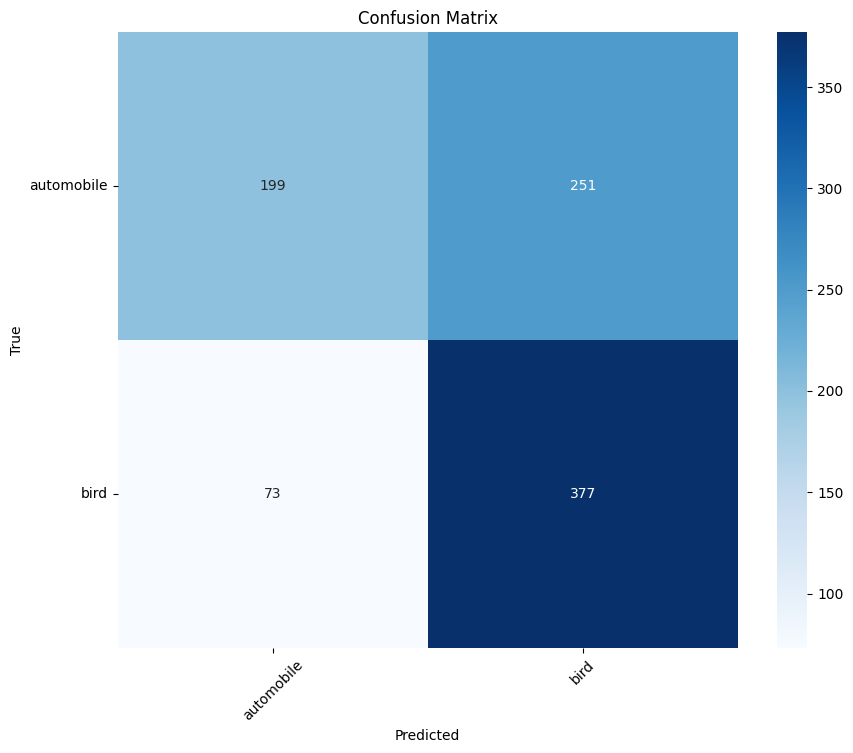


Classification Report:
              precision    recall  f1-score   support

  automobile       0.73      0.44      0.55       450
        bird       0.60      0.84      0.70       450

    accuracy                           0.64       900
   macro avg       0.67      0.64      0.63       900
weighted avg       0.67      0.64      0.63       900


Quantum Circuit Visualization:


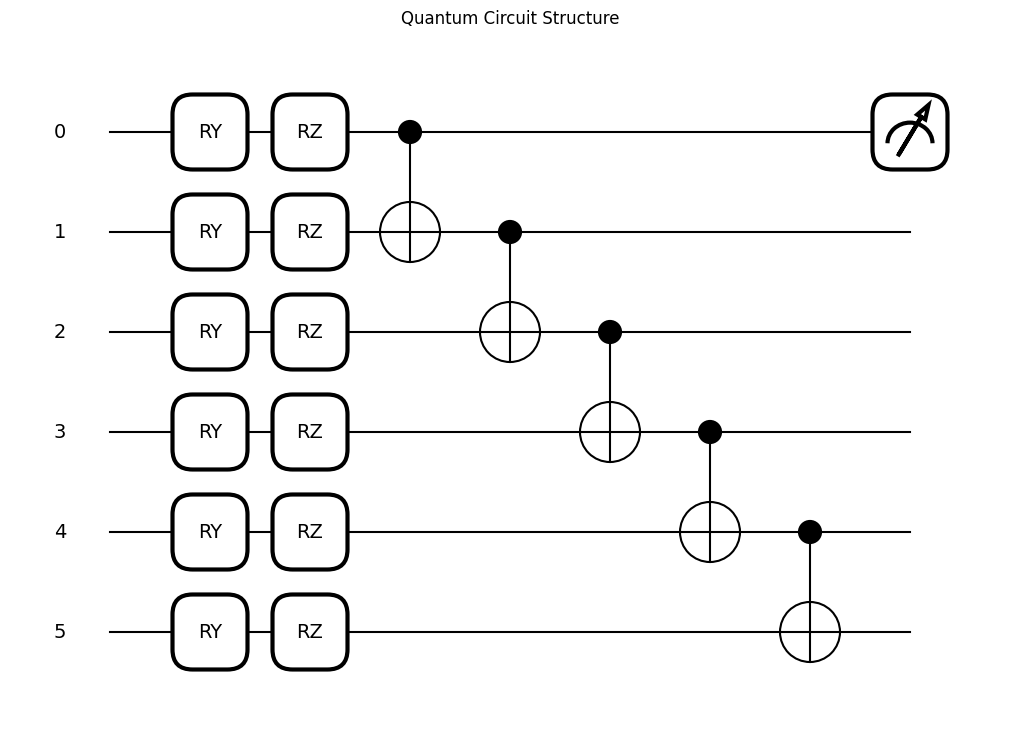

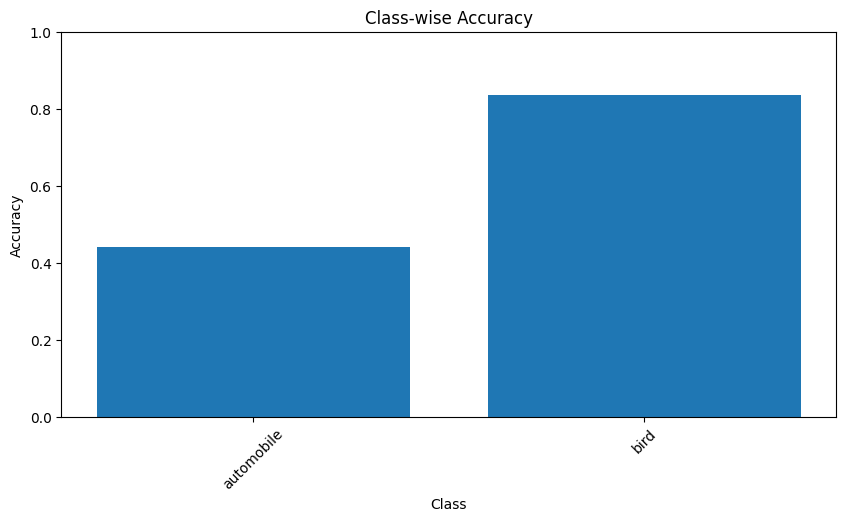


Training on classes: ['airplane', 'cat', 'ship']
Loaded 7500 training samples and 1350 test samples
Class distribution - Train: [2500 2500 2500], Test: [450 450 450]
Epoch 1/15 | Loss: 238.5303 | Train Acc: 47.1867
Epoch 2/15 | Loss: 233.6318 | Train Acc: 48.5200
Epoch 3/15 | Loss: 231.8384 | Train Acc: 48.7333
Epoch 4/15 | Loss: 230.3168 | Train Acc: 49.7200
Epoch 5/15 | Loss: 228.6399 | Train Acc: 49.8800
Epoch 6/15 | Loss: 229.6357 | Train Acc: 50.0400
Epoch 7/15 | Loss: 229.0252 | Train Acc: 50.2533
Epoch 8/15 | Loss: 228.5930 | Train Acc: 50.0133
Epoch 9/15 | Loss: 227.3899 | Train Acc: 50.6667
Epoch 10/15 | Loss: 227.5794 | Train Acc: 50.4800
Epoch 11/15 | Loss: 227.0625 | Train Acc: 50.0400
Epoch 12/15 | Loss: 226.8592 | Train Acc: 50.9600
Epoch 13/15 | Loss: 226.1677 | Train Acc: 50.7733
Epoch 14/15 | Loss: 227.0678 | Train Acc: 50.2400
Epoch 15/15 | Loss: 226.5187 | Train Acc: 50.8667

Test Accuracy: 52.9630


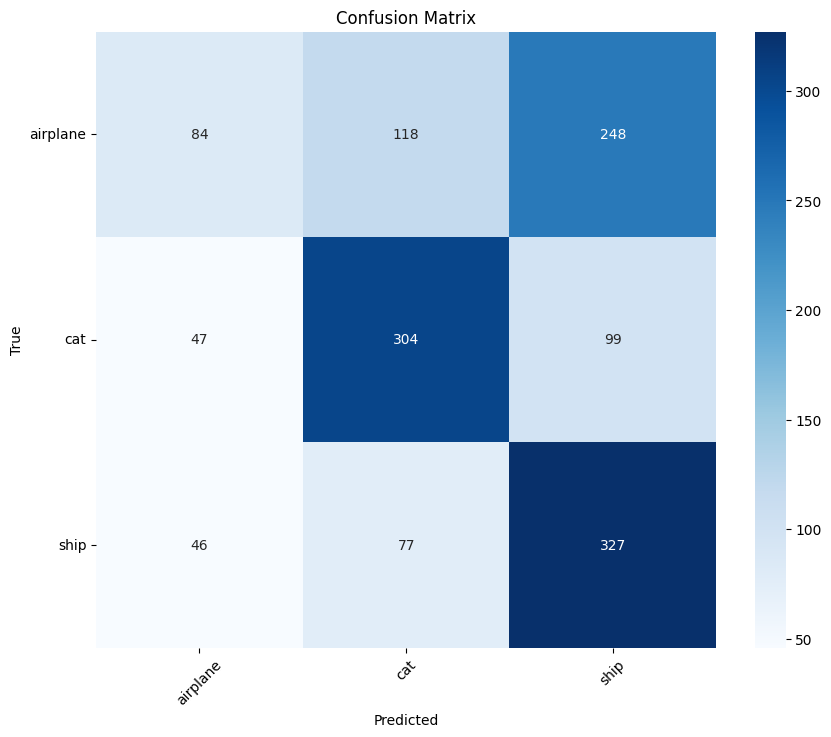


Classification Report:
              precision    recall  f1-score   support

    airplane       0.47      0.19      0.27       450
         cat       0.61      0.68      0.64       450
        ship       0.49      0.73      0.58       450

    accuracy                           0.53      1350
   macro avg       0.52      0.53      0.50      1350
weighted avg       0.52      0.53      0.50      1350


Quantum Circuit Visualization:


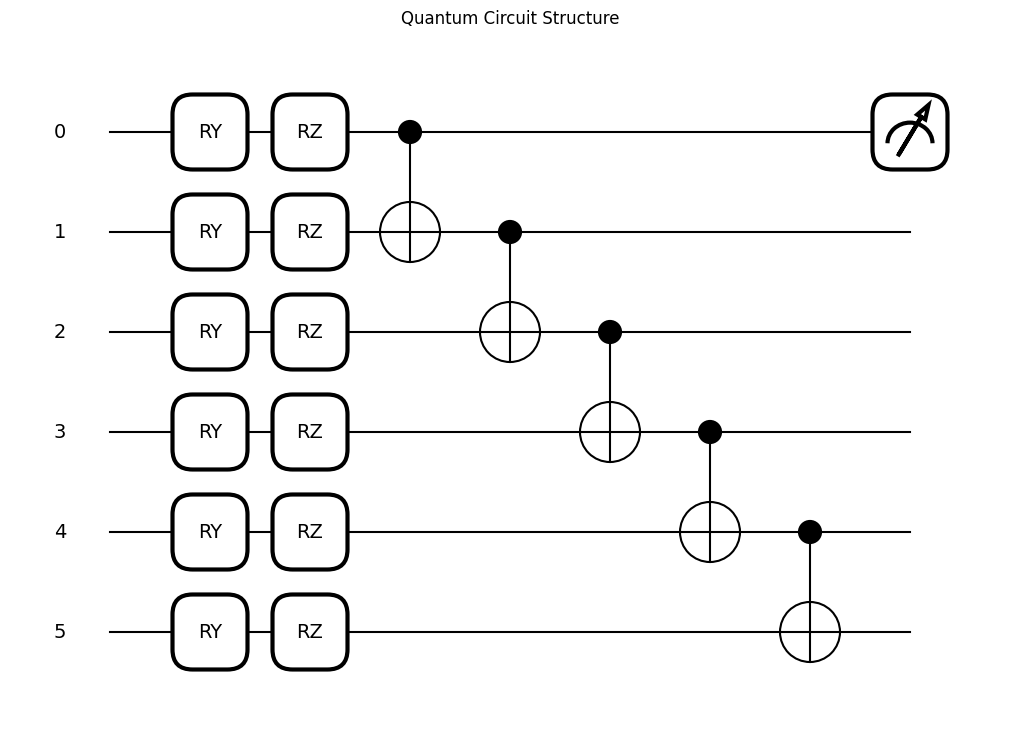

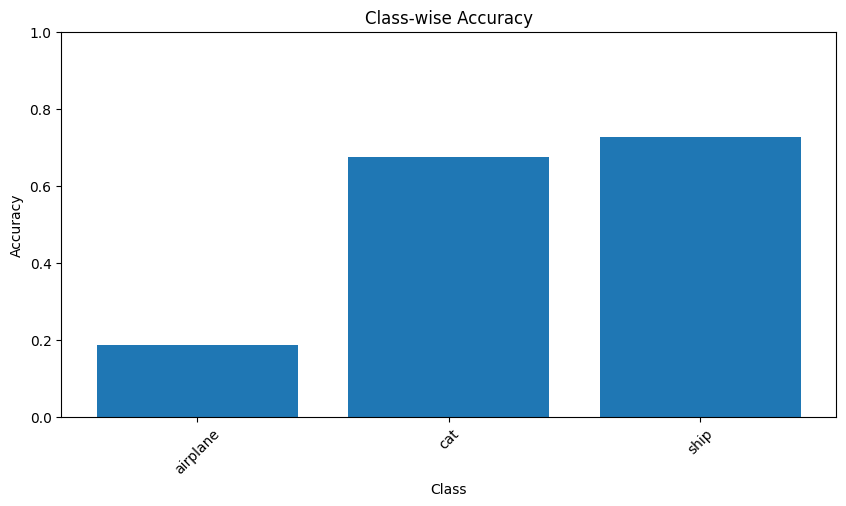


Training on classes: ['airplane', 'automobile', 'bird', 'cat', 'ship']
Loaded 12500 training samples and 2250 test samples
Class distribution - Train: [2500 2500 2500 2500 2500], Test: [450 450 450 450 450]
Epoch 1/15 | Loss: 601.6371 | Train Acc: 30.0720
Epoch 2/15 | Loss: 594.8238 | Train Acc: 31.3600
Epoch 3/15 | Loss: 593.2645 | Train Acc: 31.5040
Epoch 4/15 | Loss: 591.3534 | Train Acc: 31.3760
Epoch 5/15 | Loss: 588.4525 | Train Acc: 31.9440
Epoch 6/15 | Loss: 588.2078 | Train Acc: 32.3040
Epoch 7/15 | Loss: 586.0106 | Train Acc: 32.7040
Epoch 8/15 | Loss: 586.4187 | Train Acc: 32.5680
Epoch 9/15 | Loss: 585.2575 | Train Acc: 32.6960
Epoch 10/15 | Loss: 585.6097 | Train Acc: 32.4720
Epoch 11/15 | Loss: 584.2680 | Train Acc: 32.0080
Epoch 12/15 | Loss: 583.7132 | Train Acc: 32.9120
Epoch 13/15 | Loss: 581.6724 | Train Acc: 33.2320
Epoch 14/15 | Loss: 581.9408 | Train Acc: 33.1680
Epoch 15/15 | Loss: 582.4267 | Train Acc: 33.4880

Test Accuracy: 35.1556


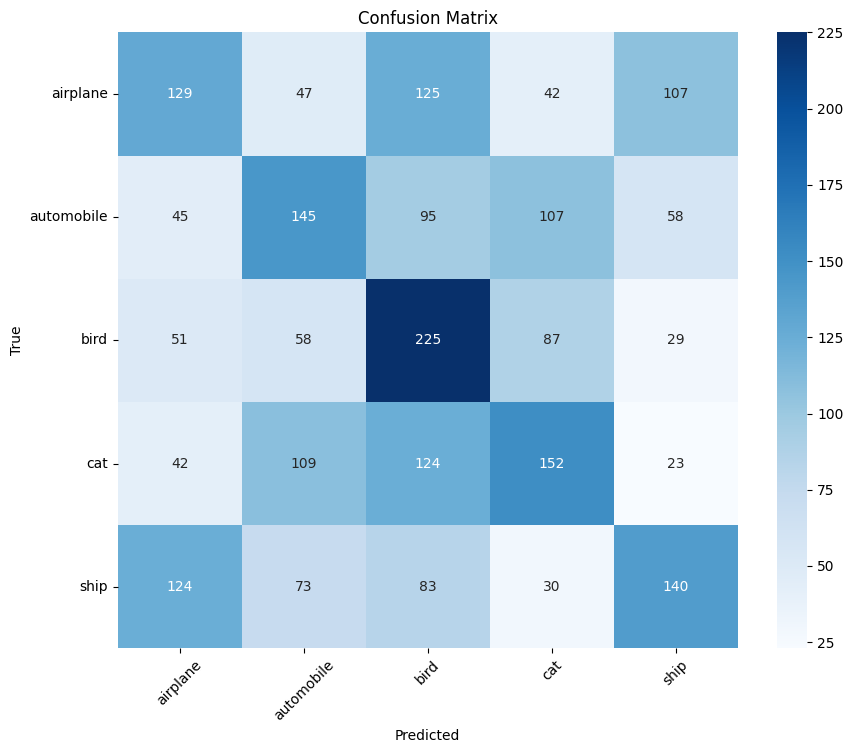


Classification Report:
              precision    recall  f1-score   support

    airplane       0.33      0.29      0.31       450
  automobile       0.34      0.32      0.33       450
        bird       0.35      0.50      0.41       450
         cat       0.36      0.34      0.35       450
        ship       0.39      0.31      0.35       450

    accuracy                           0.35      2250
   macro avg       0.35      0.35      0.35      2250
weighted avg       0.35      0.35      0.35      2250


Quantum Circuit Visualization:


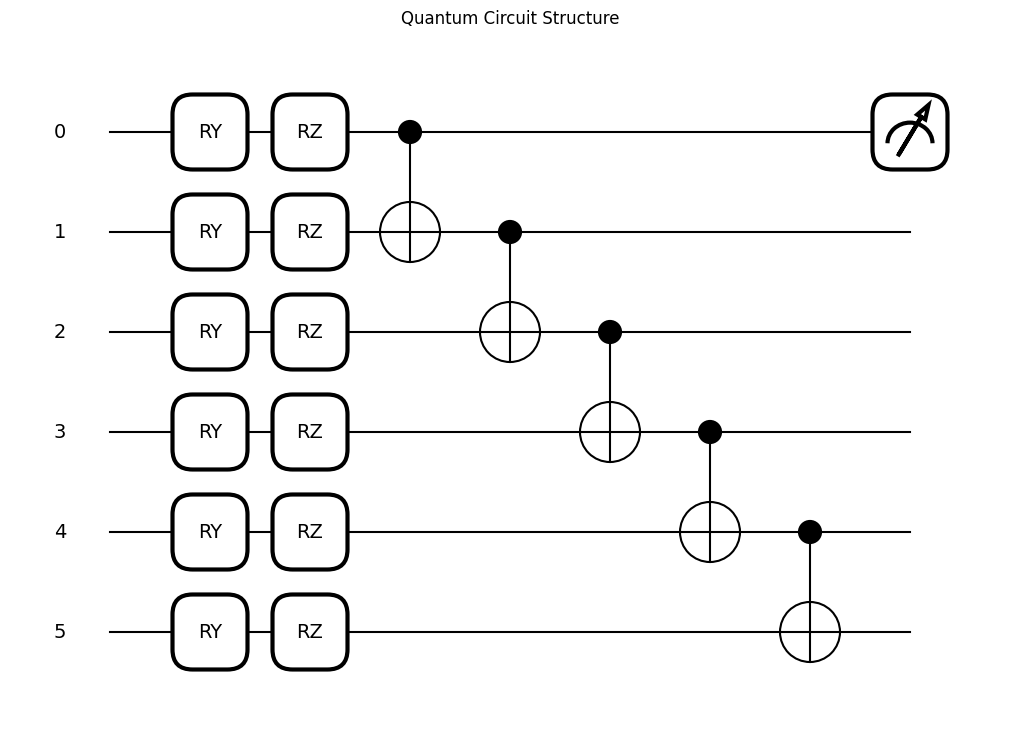

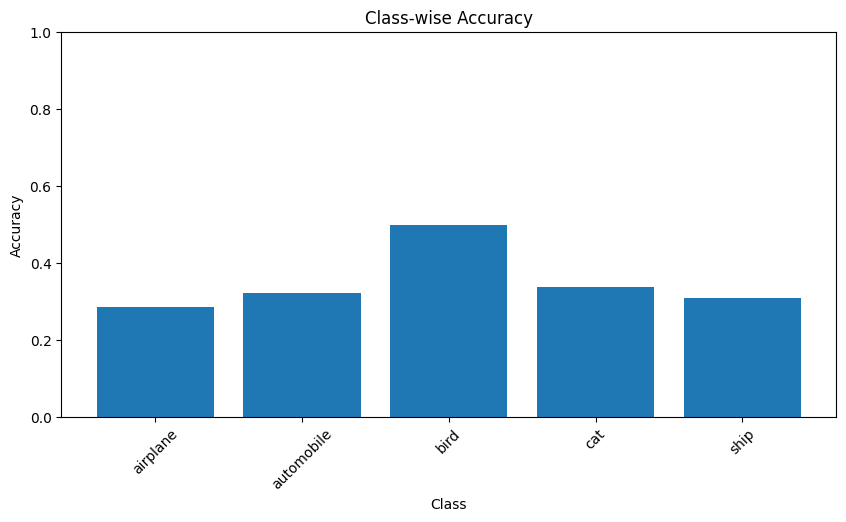


Final Results:
Classes ['automobile', 'bird']: Accuracy = 64.0000
Classes ['airplane', 'cat', 'ship']: Accuracy = 52.9630
Classes ['airplane', 'automobile', 'bird', 'cat', 'ship']: Accuracy = 35.1556


In [18]:
if __name__ == "__main__":
    # Try different class combinations
    class_combinations = [
        [1,2],           # Binary
        [0, 3, 8],        # 3-class
        [0, 1, 2, 3, 8],  # 5-class
    ]

    results = {}
    for classes in class_combinations:
        print(f"\nTraining on classes: {[cifar10_classes[c] for c in classes]}")
        acc = train_and_evaluate(
            classes=classes,
            train_samples=2500,
            test_samples=450,
            epochs=15
        )
        results[tuple(classes)] = acc

    print("\nFinal Results:")
    for classes, acc in results.items():
        print(f"Classes {[cifar10_classes[c] for c in classes]}: Accuracy = {acc*100:.4f}")